In [5]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,MinMaxScaler,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

# Feature engineering

In [8]:
df= pd.read_csv('clean_Churn.csv')

In [10]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [12]:
df['has_p'] = df['Partner'].map({'Yes':1,'No':0})

In [14]:
df['has_dep'] = df['Dependents'].map({'Yes':1,'No':0})

In [16]:
df.head(1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,has_p,has_dep
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,0


In [17]:
def household(row):
    if row['has_p'] == 1 and row['has_dep'] == 0 :
        return 'Couple'
    if row['has_p'] == 0 and row['has_dep'] ==1  :
        return 'Single Parent'
    if row['has_p'] == 1 and row['has_dep'] == 1 :
        return 'Family'
    if row['has_p'] == 0 and row['has_dep'] == 0 :
        return 'Single'
    
        

In [20]:
df['household_type'] = df.apply(household,axis=1)

In [21]:
df['household_type'].value_counts()

household_type
Single           3280
Family           1749
Couple           1653
Single Parent     361
Name: count, dtype: int64

In [22]:
df.drop(
    columns=['Partner', 'Dependents', 'has_p', 'has_dep'],
    inplace=True
)

In [26]:
df.head(2)

,customerID,gender,SeniorCitizen,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,household_type
0,7590-VHVEG,Female,0,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Couple
1,5575-GNVDE,Male,0,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,Single


In [28]:
def term(row):
    if row['tenure'] >= 24:
        return 'Yes'
    else:
        return 'No'


In [30]:
df['long_term_customer'] = df.apply(term,axis=1)

In [31]:
df.head(2)

,customerID,gender,SeniorCitizen,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,household_type,long_term_customer
0,7590-VHVEG,Female,0,1,No,No phone service,DSL,No,Yes,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Couple,No
1,5575-GNVDE,Male,0,34,Yes,No,DSL,Yes,No,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,Single,Yes


In [33]:
df['long_term_customer'].value_counts()

long_term_customer
Yes    3927
No     3116
Name: count, dtype: int64

In [35]:
df.isnull().sum()

customerID            0
gender                0
SeniorCitizen         0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges          0
Churn                 0
household_type        0
long_term_customer    0
dtype: int64

In [38]:
df.drop(columns=['customerID'],inplace=True)

In [39]:
df.columns

Index(['gender', 'SeniorCitizen', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'household_type', 'long_term_customer'],
      dtype='object')

# Splitiing the data

In [43]:
X = df.drop(columns=['Churn'])
y = df['Churn'].map({'No': 0, 'Yes': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
y_train.value_counts(normalize=True)

Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

In [47]:
y_train.value_counts()

Churn
0    4139
1    1495
Name: count, dtype: int64

In [48]:
y_test.value_counts(normalize=True)

Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64

# Encoding and scaling 

In [52]:
n_cols = ['tenure','MonthlyCharges','TotalCharges']
c_cols = X.select_dtypes(include='object').columns.tolist()


In [54]:
for col in c_cols:
    
    print(f"{col}->{df[col].unique()}")

gender->['Female' 'Male']
PhoneService->['No' 'Yes']
MultipleLines->['No phone service' 'No' 'Yes']
InternetService->['DSL' 'Fiber optic' 'No']
OnlineSecurity->['No' 'Yes' 'No internet service']
OnlineBackup->['Yes' 'No' 'No internet service']
DeviceProtection->['No' 'Yes' 'No internet service']
TechSupport->['No' 'Yes' 'No internet service']
StreamingTV->['No' 'Yes' 'No internet service']
StreamingMovies->['No' 'Yes' 'No internet service']
Contract->['Month-to-month' 'One year' 'Two year']
PaperlessBilling->['Yes' 'No']
PaymentMethod->['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
household_type->['Couple' 'Single' 'Single Parent' 'Family']
long_term_customer->['No' 'Yes']


In [55]:
binary_cols = ['gender','PhoneService','PaperlessBilling','long_term_customer']
ohe_cols=['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaymentMethod',
          'household_type']
ord_cols=['Contract']

In [56]:
all_cols = binary_cols + ohe_cols + ord_cols + n_cols

print(len(all_cols))
print(len(set(all_cols)))
print(set(X_train.columns) - set(all_cols))

18
18
{'SeniorCitizen'}


In [60]:
print(y_train.unique())
print(y_test.unique())

[0 1]
[0 1]


In [61]:


Preprocessor= ColumnTransformer([
    
    (
        'binary',
        OrdinalEncoder(categories=[
            ['Female', 'Male'],
            ['No', 'Yes'],
            ['No', 'Yes'],
            ['No', 'Yes']
        ]),
        binary_cols
    ),

    (
        'ohe',
        OneHotEncoder(handle_unknown='ignore'),
        ohe_cols
    ),

    (
        'ord',
        OrdinalEncoder(categories=[[
            'Month-to-month',
            'One year',
            'Two year'
        ]]),
        ord_cols
    ),
    (  'scale',
    StandardScaler(),
    n_cols)

], remainder='passthrough')

In [63]:


Preprocessor2= ColumnTransformer([
    
    (
        'binary',
        OrdinalEncoder(categories=[
            ['Female', 'Male'],
            ['No', 'Yes'],
            ['No', 'Yes'],
            ['No', 'Yes']
        ]),
        binary_cols
    ),

    (
        'ohe',
        OneHotEncoder(handle_unknown='ignore'),
        ohe_cols
    ),

    (
        'ord',
        OrdinalEncoder(categories=[[
            'Month-to-month',
            'One year',
            'Two year'
        ]]),
        ord_cols
    )

], remainder='passthrough')

In [64]:
all_cols = binary_cols + ohe_cols + ord_cols + n_cols

print(set(X_train.columns) - set(all_cols))

{'SeniorCitizen'}


## Baseline Model

In [69]:
pipe = Pipeline([
    ('preprocessor',Preprocessor),
    ('model',LogisticRegression())
])


In [71]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('binary',
                                                  OrdinalEncoder(categories=[['Female',
                                                                              'Male'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes']]),
                                                  ['gender', 'PhoneService',
                                                   'PaperlessBilling',
                                                   'long_term_customer']),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'PaymentMethod',
                                                   'household_type']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['Month-to-month',
                                                                              'One '
                                                                              'year',
                                                                              'Two '
                                                                              'year']]),
                                                  ['Contract']),
                                                 ('scale', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('model', LogisticRegression())])

In [72]:
y_pred = pipe.predict(X_test)

In [73]:
acc = accuracy_score(y_test,y_pred)
print(acc)

0.8069552874378992


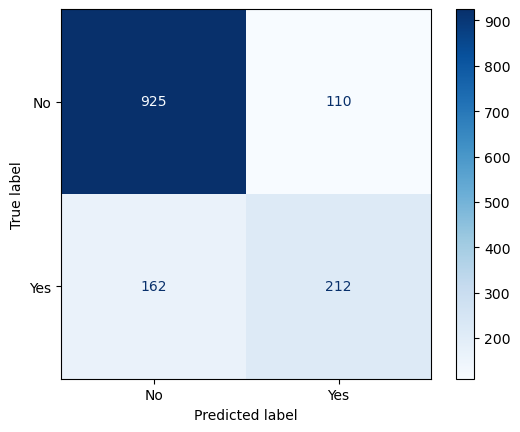

In [74]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['No','Yes'])
disp.plot(cmap='Blues')
plt.show()

1409 test customers
        ↓
1035 didn't churn
374 churned
        ↓
Model correctly identified:
925 non-churners
212 churners

Model made mistakes:
110 false churn predictions
162 missed churners

In [77]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [80]:
y_train_pred = pipe.predict(X_train)
y_test_pred = pipe.predict(X_test)

In [81]:
print("For Train-Set - > ")
acc = accuracy_score(y_train,y_train_pred)

print(acc)
from sklearn.metrics import classification_report

print(classification_report(y_train, y_train_pred))

print("For Test-Set - > ")
acc = accuracy_score(y_test,y_test_pred)
print(acc)
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred))

For Train-Set - > 
0.8058217962371317
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      4139
           1       0.66      0.55      0.60      1495

    accuracy                           0.81      5634
   macro avg       0.75      0.72      0.74      5634
weighted avg       0.80      0.81      0.80      5634

For Test-Set - > 
0.8069552874378992
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [82]:
X_train_encoded = Preprocessor.fit_transform(X_train)

feature_names = Preprocessor.get_feature_names_out()

print(len(feature_names))
print(feature_names)

41
['binary__gender' 'binary__PhoneService' 'binary__PaperlessBilling'
 'binary__long_term_customer' 'ohe__MultipleLines_No'
 'ohe__MultipleLines_No phone service' 'ohe__MultipleLines_Yes'
 'ohe__InternetService_DSL' 'ohe__InternetService_Fiber optic'
 'ohe__InternetService_No' 'ohe__OnlineSecurity_No'
 'ohe__OnlineSecurity_No internet service' 'ohe__OnlineSecurity_Yes'
 'ohe__OnlineBackup_No' 'ohe__OnlineBackup_No internet service'
 'ohe__OnlineBackup_Yes' 'ohe__DeviceProtection_No'
 'ohe__DeviceProtection_No internet service' 'ohe__DeviceProtection_Yes'
 'ohe__TechSupport_No' 'ohe__TechSupport_No internet service'
 'ohe__TechSupport_Yes' 'ohe__StreamingTV_No'
 'ohe__StreamingTV_No internet service' 'ohe__StreamingTV_Yes'
 'ohe__StreamingMovies_No' 'ohe__StreamingMovies_No internet service'
 'ohe__StreamingMovies_Yes' 'ohe__PaymentMethod_Bank transfer (automatic)'
 'ohe__PaymentMethod_Credit card (automatic)'
 'ohe__PaymentMethod_Electronic check' 'ohe__PaymentMethod_Mailed check'
 'o

### Multicollinearity Analysis

During EDA, the correlation heatmap showed a strong positive correlation
between `tenure` and `TotalCharges` (correlation = 0.83), indicating possible
multicollinearity.

Since Logistic Regression can be affected by multicollinearity, VIF
(Variance Inflation Factor) was used to further investigate the numerical
features.

In [84]:
x_vif_cols = X_train[['tenure','MonthlyCharges','TotalCharges']]

vif = pd.DataFrame()
vif['Feature'] = x_vif_cols.columns
vif['VIF'] = [
    variance_inflation_factor(x_vif_cols.values,i)
    for i in range(x_vif_cols.shape[1])
]

print(vif)


          Feature       VIF
0          tenure  6.466103
1  MonthlyCharges  3.385469
2    TotalCharges  8.212960


### Multicollinearity Experiment Conclusion

The VIF analysis indicated potential multicollinearity between `tenure`
(VIF = 6.47) and `TotalCharges` (VIF = 8.21).

To investigate whether this affected model performance, each feature was
removed separately and the Logistic Regression model was retrained.

- Removing `TotalCharges` resulted in a churn F1-score of 0.59.
- Removing `tenure` resulted in a churn F1-score of 0.60.
- The baseline model containing both features achieved a churn F1-score of 0.61.

Since removing either feature reduced performance, both `tenure` and
`TotalCharges` were retained in the feature set.

## Trying differnt models


In [87]:
models = {
    'Decision Tree': (Preprocessor2, DecisionTreeClassifier()),
    'Random Forest': (Preprocessor2, RandomForestClassifier()),
    'Gradient Boosting': (Preprocessor2, GradientBoostingClassifier()),
    'XGBoost': (Preprocessor2, XGBClassifier()),
    'Logistic Regression': (Preprocessor, LogisticRegression())
}

for name, (preprocessor, model) in models.items():

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Decision Tree
              precision    recall  f1-score   support

           0       0.81      0.80      0.81      1035
           1       0.47      0.49      0.48       374

    accuracy                           0.72      1409
   macro avg       0.64      0.65      0.64      1409
weighted avg       0.72      0.72      0.72      1409


Random Forest
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.77      0.79      0.78      1409


Gradient Boosting
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79  

### Model Comparison

After evaluating multiple classification models using the same training and testing data, their performance was compared using precision, recall, and F1-score for the **Churn (Yes)** class.

The results were:

- **Logistic Regression:** Precision = 0.66, Recall = 0.57, F1-score = 0.61
- **Gradient Boosting:** Precision = 0.66, Recall = 0.52, F1-score = 0.59
- **Random Forest:** Precision = 0.63, Recall = 0.49, F1-score = 0.55
- **XGBoost:** Precision = 0.59, Recall = 0.51, F1-score = 0.54
- **Decision Tree:** Precision = 0.48, Recall = 0.51, F1-score = 0.49

Logistic Regression achieved the highest F1-score and recall at the default
threshold. Gradient Boosting was the closest alternative and showed strong
ROC-AUC and PR-AUC performance.

Therefore, Logistic Regression and Gradient Boosting were retained as
promising models for further cross-validation and hyperparameter tuning..

In [89]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, (preprocessor, model) in models.items():

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring='f1'
    )

    print(f"{name}")
    print(f"F1 scores: {scores}")
    print(f"Mean F1: {scores.mean():.3f}")
    print(f"Std F1: {scores.std():.3f}")
    print()

Decision Tree
F1 scores: [0.4829932  0.47236181 0.51764706 0.50675676 0.4869281 ]
Mean F1: 0.493
Std F1: 0.016

Random Forest
F1 scores: [0.53258845 0.51055662 0.57844991 0.49808429 0.53620352]
Mean F1: 0.531
Std F1: 0.028

Gradient Boosting
F1 scores: [0.5682243  0.55822551 0.6061706  0.59149723 0.61363636]
Mean F1: 0.588
Std F1: 0.021

XGBoost
F1 scores: [0.53790614 0.52650823 0.57246377 0.52823315 0.56978967]
Mean F1: 0.547
Std F1: 0.020

Logistic Regression
F1 scores: [0.58909091 0.54744526 0.59259259 0.64604811 0.60263653]
Mean F1: 0.596
Std F1: 0.032



### Cross-Validation

To obtain a more reliable estimate of model performance, 5-fold stratified
cross-validation was performed using F1-score as the evaluation metric for
the Churn class.

Logistic Regression achieved the highest mean F1-score of 0.596, followed
closely by Gradient Boosting with a mean F1-score of 0.588. Random Forest,
XGBoost, and Decision Tree achieved lower mean F1-scores.

Although Logistic Regression had the highest mean F1-score, Gradient Boosting
showed a lower standard deviation (0.022 compared with 0.032), indicating
more consistent performance across the folds.

Therefore, Logistic Regression remains the current best-performing model,
while Gradient Boosting is retained as a strong alternative for further
evaluation and hyperparameter tuning.

In [91]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

for name, (preprocessor, model) in models.items():

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)

    y_prob = pipe.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)

    print(f"{name} ROC-AUC: {auc:.3f}")

Decision Tree ROC-AUC: 0.654
Random Forest ROC-AUC: 0.820
Gradient Boosting ROC-AUC: 0.844
XGBoost ROC-AUC: 0.821
Logistic Regression ROC-AUC: 0.842


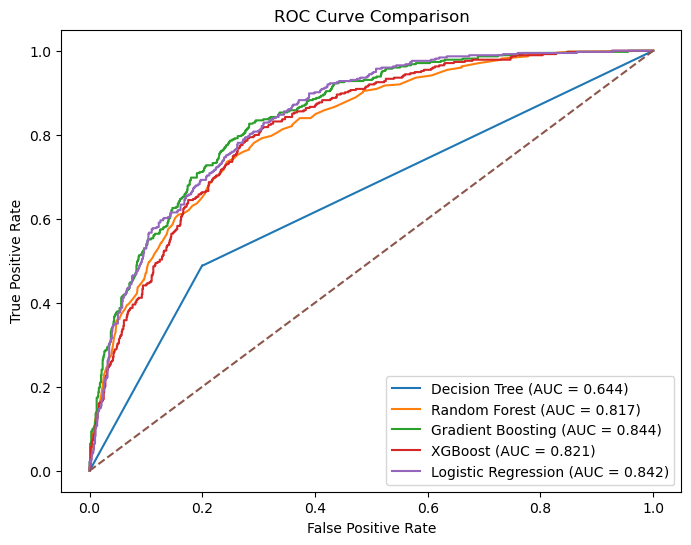

In [92]:
plt.figure(figsize=(8, 6))

for name, (preprocessor, model) in models.items():

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)

    y_prob = pipe.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

Decision Tree PR-AUC: 0.366
Random Forest PR-AUC: 0.618
Gradient Boosting PR-AUC: 0.663
XGBoost PR-AUC: 0.608
Logistic Regression PR-AUC: 0.634


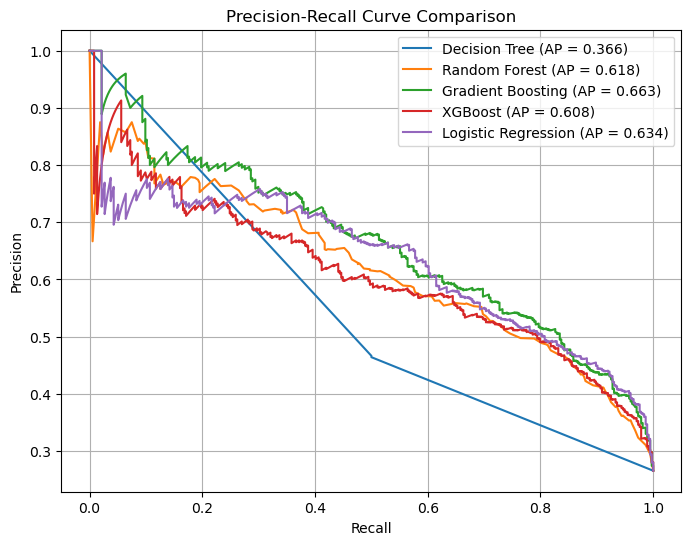

In [93]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, (preprocessor, model) in models.items():

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)

    y_prob = pipe.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    pr_auc = average_precision_score(y_test, y_prob)

    print(f"{name} PR-AUC: {pr_auc:.3f}")

    plt.plot(
        recall,
        precision,
        label=f'{name} (AP = {pr_auc:.3f})'
    )

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.grid()
plt.show()

### ROC-AUC and Precision-Recall Analysis

ROC-AUC and Precision-Recall analysis were performed to evaluate the models
beyond the default classification threshold.

The results showed that **Logistic Regression and Gradient Boosting were the
most promising models**.

- Logistic Regression achieved a ROC-AUC of **0.842** and PR-AUC of **0.634**.
- Gradient Boosting achieved a ROC-AUC of **0.844** and PR-AUC of **0.663**.

Gradient Boosting showed slightly better overall class-separation ability and
positive-class performance, while Logistic Regression achieved the highest
F1-score at the default threshold.

Therefore, **Logistic Regression and Gradient Boosting were selected as the
promising candidate models for the next stage: hyperparameter tuning**.

## Hyperparameter tuning the promising models

In [118]:
promising_models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', Preprocessor),
        ('model', LogisticRegression())
    ]),

    'Gradient Boosting': Pipeline([
        ('preprocessor', Preprocessor2),
        ('model', GradientBoostingClassifier())
    ])
}
param_lr = {
    'model__C': [0.001,0.01,0.1,1,10,100],
    'model__solver':['liblinear','lbfgs']
}

param_gb = {
    'model__n_estimators':[50,100,150,200,300],
    'model__learning_rate':[0.01,0.05,0.1,0.2],
    'model__max_depth':[2,3,4,5],
    'model__min_samples_split':[2,5,10,20],
    'model__min_samples_leaf':[1,2,4,8]
}

param_grids = {
    'Logistic Regression': param_lr,
    'Gradient Boosting': param_gb
}
tuned_models = {}

for name, model in promising_models.items():

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grids[name],
        n_iter=10,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        random_state=42
    )

    random_search.fit(X_train, y_train)

    tuned_models[name] = random_search.best_estimator_

    print(f"\n{name}")
    print("Best Parameters:", random_search.best_params_)
    print("Best CV F1:", random_search.best_score_)


Logistic Regression
Best Parameters: {'model__solver': 'lbfgs', 'model__C': 100}
Best CV F1: 0.5997578224253168

Gradient Boosting
Best Parameters: {'model__n_estimators': 50, 'model__min_samples_split': 20, 'model__min_samples_leaf': 4, 'model__max_depth': 3, 'model__learning_rate': 0.2}
Best CV F1: 0.5879073894512101


In [120]:
best_lr = tuned_models['Logistic Regression']

y_pred_lr = best_lr.predict(X_test)
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]

print("Logistic Regression - Test Results")
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("PR-AUC:", average_precision_score(y_test, y_prob_lr))

Logistic Regression - Test Results
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

Confusion Matrix:
[[920 115]
 [168 206]]
ROC-AUC: 0.8405900436590974
PR-AUC: 0.6252534781002417


In [122]:
best_gb = tuned_models['Gradient Boosting']

y_pred_gb = best_gb.predict(X_test)
y_prob_gb = best_gb.predict_proba(X_test)[:, 1]

print("Gradient Boosting - Test Results")
print(classification_report(y_test, y_pred_gb, target_names=['No Churn', 'Churn']))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))
print("PR-AUC:", average_precision_score(y_test, y_prob_gb))

Gradient Boosting - Test Results
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409

Confusion Matrix:
[[935 100]
 [179 195]]
ROC-AUC: 0.8424668681701929
PR-AUC: 0.6502476521487661


## Hyperparameter Tuning

The promising models identified during the evaluation stage were further
optimized using **RandomizedSearchCV** with 5-fold cross-validation.

RandomizedSearchCV was used to explore different combinations of
hyperparameters while optimizing for the **F1-score**, which was selected as
the primary evaluation metric to maintain a balance between precision and
recall for the churn class.

The best configurations obtained were:

- **Logistic Regression:** `C = 100`, `solver = lbfgs`
- **Gradient Boosting:** `n_estimators = 50`, `learning_rate = 0.2`,
  `max_depth = 3`, `min_samples_split = 20`,
  `min_samples_leaf = 4`

The improvement in cross-validation F1-score was small for both models,
indicating that hyperparameter tuning alone did not significantly improve
their performance. The tuned models were therefore evaluated on the
unseen test set before considering further improvements.

## Threshold tuning

In [130]:
import numpy as np
import pandas as pd

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score
)


#1.Get out-of-fold probabilities from the TRAINING data
y_prob_cv = cross_val_predict(
    best_lr,
    X_train,
    y_train,
    cv=5,
    method='predict_proba',
    n_jobs=-1
)[:, 1]



#2. Search for the best classification threshold
thresholds = np.arange(0.01, 0.90, 0.01)

results = []

best_thresh = 0.5
best_f1 = 0.0

for thresh in thresholds:

   
    y_pred_cv = (y_prob_cv >= thresh).astype(int)

    thresh_precision = precision_score(
        y_train,
        y_pred_cv,
        zero_division=0
    )

    thresh_recall = recall_score(
        y_train,
        y_pred_cv,
        zero_division=0
    )

    thresh_f1 = f1_score(
        y_train,
        y_pred_cv,
        zero_division=0
    )

    results.append({
        'Threshold': thresh,
        'Precision': thresh_precision,
        'Recall': thresh_recall,
        'F1-Score': thresh_f1
    })

    if thresh_f1 > best_f1:
        best_f1 = thresh_f1
        best_thresh = thresh
        
#3.Display the best thresholds
df_results = pd.DataFrame(results)
print("=Top 5 Thresholds Based on CV F1=")
print(
    df_results
    .sort_values(by='F1-Score', ascending=False)
    .head(5)
    .to_string(index=False)
)
print(f"OPTIMAL THRESHOLD: {best_thresh:.2f}")
print(f"BEST CV F1: {best_f1:.4f}")

#4.Now evaluate the LOCKED threshold on the TEST set
y_prob_test = best_lr.predict_proba(X_test)[:, 1]

y_pred_test = (y_prob_test >= best_thresh).astype(int)

#5.Final test metrics at the selected threshold
print("\n =Final Test Results=")

print(
    classification_report(
        y_test,
        y_pred_test,
        target_names=['No Churn', 'Churn']
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))

=Top 5 Thresholds Based on CV F1=
 Threshold  Precision   Recall  F1-Score
      0.32   0.551061 0.747157  0.634299
      0.30   0.539981 0.767893  0.634079
      0.29   0.534404 0.779264  0.634014
      0.34   0.564263 0.722408  0.633617
      0.33   0.556853 0.733779  0.633189
OPTIMAL THRESHOLD: 0.32
BEST CV F1: 0.6343

 =Final Test Results=
              precision    recall  f1-score   support

    No Churn       0.89      0.77      0.82      1035
       Churn       0.53      0.72      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409

Confusion Matrix:
[[794 241]
 [103 271]]


In [141]:
import numpy as np
import pandas as pd

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score
)


#1.Get out-of-fold probabilities from the TRAINING data
y_prob_cv = cross_val_predict(
    best_gb,
    X_train,
    y_train,
    cv=5,
    method='predict_proba',
    n_jobs=-1
)[:, 1]



#2. Search for the best classification threshold
thresholds = np.arange(0.01, 0.90, 0.01)

results = []

best_thresh = 0.5
best_f1 = 0.0

for thresh in thresholds:

   
    y_pred_cv = (y_prob_cv >= thresh).astype(int)

    thresh_precision = precision_score(
        y_train,
        y_pred_cv,
        zero_division=0
    )

    thresh_recall = recall_score(
        y_train,
        y_pred_cv,
        zero_division=0
    )

    thresh_f1 = f1_score(
        y_train,
        y_pred_cv,
        zero_division=0
    )

    results.append({
        'Threshold': thresh,
        'Precision': thresh_precision,
        'Recall': thresh_recall,
        'F1-Score': thresh_f1
    })

    if thresh_f1 > best_f1:
        best_f1 = thresh_f1
        best_thresh = thresh

#3.Display the best thresholds
df_results = pd.DataFrame(results)
print("=Top 5 Thresholds Based on CV F1=")
print(
    df_results
    .sort_values(by='F1-Score', ascending=False)
    .head(5)
    .to_string(index=False)
)
print(f"OPTIMAL THRESHOLD: {best_thresh:.2f}")
print(f"BEST CV F1: {best_f1:.4f}")

#4.Now evaluate the LOCKED threshold on the TEST set
y_prob_test = best_gb.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= best_thresh).astype(int)

#5.Final test metrics at the selected threshold
print("\n =Final Test Results=")
print(
    classification_report(
        y_test,
        y_pred_test,
        target_names=['No Churn', 'Churn']
    )
)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))

=Top 5 Thresholds Based on CV F1=
 Threshold  Precision   Recall  F1-Score
      0.34   0.572045 0.709030  0.633214
      0.32   0.559278 0.725753  0.631732
      0.35   0.577543 0.694983  0.630844
      0.33   0.565148 0.713712  0.630801
      0.31   0.551984 0.735117  0.630522
OPTIMAL THRESHOLD: 0.34
BEST CV F1: 0.6332

 =Final Test Results=
              precision    recall  f1-score   support

    No Churn       0.89      0.80      0.84      1035
       Churn       0.56      0.71      0.63       374

    accuracy                           0.78      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.78      0.78      1409

Confusion Matrix:
[[827 208]
 [107 267]]


## Threshold Tuning

Since the default classification threshold of `0.50` did not provide the
desired balance between precision and recall, threshold tuning was performed
for both **Logistic Regression** and **Gradient Boosting**.

Out-of-fold probabilities from the training data were used to evaluate
different classification thresholds without using the test set for threshold
selection. The threshold producing the highest cross-validation F1-score was
selected for each model.

- **Logistic Regression:** Optimal threshold = **0.32**
- **Gradient Boosting:** Optimal threshold = **0.34**

The selected thresholds were then applied to the unseen test set to compare
the final performance of both models.

In [128]:
# Selected final model and threshold
final_model = best_lr
final_threshold = 0.32

y_prob_test = final_model.predict_proba(X_test)[:, 1]


y_pred_final = (y_prob_test >= final_threshold).astype(int)


print("Final Logistic Regression Test Results")
print(classification_report(
    y_test,
    y_pred_final,
    target_names=['No Churn', 'Churn']
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_test))
print("PR-AUC:", average_precision_score(y_test, y_prob_test))

Final Logistic Regression Test Results
              precision    recall  f1-score   support

    No Churn       0.89      0.77      0.82      1035
       Churn       0.53      0.72      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409

Confusion Matrix:
[[794 241]
 [103 271]]
ROC-AUC: 0.8405900436590974
PR-AUC: 0.6252534781002417


## Final Model Evaluation

After model comparison, cross-validation, hyperparameter tuning, and
threshold analysis, **Logistic Regression** was selected as the final model.

The classification threshold was changed from the default `0.50` to
**0.32**, as this threshold provided the best F1-score during the
cross-validation-based threshold analysis.

The final model was then evaluated on the previously unseen test set.

### Final Test Performance

- **Accuracy:** 0.76
- **Churn Precision:** 0.53
- **Churn Recall:** 0.72
- **Churn F1-score:** 0.61
- **ROC-AUC:** 0.841
- **PR-AUC:** 0.625

The final model correctly identified **271 out of 374 actual churn customers**,
resulting in approximately **72% recall** for the churn class.

Compared with the baseline model, threshold optimization substantially
improved churn recall from approximately **55% to 72%**, while maintaining a
similar F1-score.

The final model provides a reasonable balance between identifying potential
churn customers and limiting false positive predictions.

In [146]:
final_model = best_lr
import pickle

pickle.dump(
    final_model,
    open("Churn_Predictor_Model.pkl", "wb")
)